In [1]:
import sqlite3

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Carga de la tabla drivers

drivers = pd.read_csv(
    "../data/drivers.csv",
    sep=",",
    thousands=None,
    decimal=".",
)
drivers.head()

,driverId,name,ssn,location,certified,wage-plan
0,10,George Vetticaden,621011971,244-4532 Nulla Rd.,N,miles
1,11,Jamie Engesser,262112338,366-4125 Ac Street,N,miles
2,12,Paul Coddin,198041975,Ap #622-957 Risus. Street,Y,hours
3,13,Joe Niemiec,139907145,2071 Hendrerit. Ave,Y,hours
4,14,Adis Cesir,820812209,Ap #810-1228 In St.,Y,hours


In [3]:
# Carga de la tabla timesheet
timesheet = pd.read_csv(
    "../data/timesheet.csv",
    sep=",",
    thousands=None,
    decimal=".",
)
timesheet.head()

,driverId,week,hours-logged,miles-logged
0,10,1,70,3300
1,10,2,70,3300
2,10,3,60,2800
3,10,4,70,3100
4,10,5,70,3200


In [4]:
# Conexión a la base de datos SQLite y almacena las tablas

connection = sqlite3.connect("../temp/db.sqlite")

drivers.to_sql("drivers_raw", connection, if_exists="replace", index=False)
timesheet.to_sql("timesheet_raw", connection, if_exists="replace", index=False)

1768

In [5]:
# Crea vistas para las tablas drivers y timesheet

connection.executescript(
    """
    DROP VIEW IF EXISTS drivers;
    DROP VIEW IF EXISTS timesheet;

    CREATE VIEW drivers AS
    SELECT
        driverId AS driver_id,
        name,
        ssn,
        location,
        certified,
        "wage-plan" AS wage_plan
    FROM drivers_raw;

    CREATE VIEW timesheet AS
    SELECT
        driverId AS driver_id,
        week,
        "hours-logged" AS hours_logged,
        "miles-logged" AS miles_logged
    FROM timesheet_raw;
    """
)
connection.commit()

In [6]:
# Tablas y vistas disponibles en la base de datos

sql = """
SELECT
    name,
    type
FROM sqlite_master
WHERE type IN ('table', 'view')
ORDER BY type, name;
"""

pd.read_sql_query(sql, connection)

,name,type
0,drivers_raw,table
1,timesheet_raw,table
2,driver_summary,view
3,drivers,view
4,timesheet,view


In [7]:
# Cinco primeras filas de la tabla de conductores
sql = """
SELECT *
FROM drivers
LIMIT 5;
"""

pd.read_sql_query(sql, connection)

,driver_id,name,ssn,location,certified,wage_plan
0,10,George Vetticaden,621011971,244-4532 Nulla Rd.,N,miles
1,11,Jamie Engesser,262112338,366-4125 Ac Street,N,miles
2,12,Paul Coddin,198041975,Ap #622-957 Risus. Street,Y,hours
3,13,Joe Niemiec,139907145,2071 Hendrerit. Ave,Y,hours
4,14,Adis Cesir,820812209,Ap #810-1228 In St.,Y,hours


In [8]:
# Cinco primeras filas de los registros semanales
sql = """
SELECT *
FROM timesheet
LIMIT 5;
"""

pd.read_sql_query(sql, connection)

,driver_id,week,hours_logged,miles_logged
0,10,1,70,3300
1,10,2,70,3300
2,10,3,60,2800
3,10,4,70,3100
4,10,5,70,3200


In [9]:
# Media de las horas y las millas de cada conductor
sql = """
SELECT
    driver_id,
    AVG(hours_logged) AS mean_hours_logged,
    AVG(miles_logged) AS mean_miles_logged
FROM timesheet
GROUP BY driver_id
ORDER BY driver_id;
"""

mean_timesheet = pd.read_sql_query(sql, connection)
mean_timesheet.head()

,driver_id,mean_hours_logged,mean_miles_logged
0,10,62.153846,2829.807692
1,11,70.038462,3448.076923
2,12,50.750000,2614.653846
3,13,52.442308,2579.346154
4,14,53.480769,2627.384615


In [10]:
# Registros con valores por debajo de la media del grupo
sql = """
SELECT
    driver_id,
    week,
    hours_logged,
    miles_logged,
    AVG(hours_logged) OVER (
        PARTITION BY driver_id
    ) AS mean_hours_logged
FROM timesheet
ORDER BY driver_id, week;
"""

timesheet_with_means = pd.read_sql_query(sql, connection)
timesheet_with_means.head()

,driver_id,week,hours_logged,miles_logged,mean_hours_logged
0,10,1,70,3300,62.153846
1,10,2,70,3300,62.153846
2,10,3,60,2800,62.153846
3,10,4,70,3100,62.153846
4,10,5,70,3200,62.153846


In [11]:
sql = """
WITH timesheet_with_means AS (
    SELECT
        driver_id,
        week,
        hours_logged,
        miles_logged,
        AVG(hours_logged) OVER (
            PARTITION BY driver_id
        ) AS mean_hours_logged
    FROM timesheet
)
SELECT
    driver_id,
    week,
    hours_logged,
    miles_logged,
    mean_hours_logged
FROM timesheet_with_means
WHERE hours_logged < mean_hours_logged
ORDER BY driver_id, week;
"""

timesheet_below = pd.read_sql_query(sql, connection)
display(timesheet_below.head(), timesheet_below.tail())

,driver_id,week,hours_logged,miles_logged,mean_hours_logged
0,10,3,60,2800,62.153846
1,10,10,50,2500,62.153846
2,10,20,30,1200,62.153846
3,10,21,50,2500,62.153846
4,10,26,60,2600,62.153846


,driver_id,week,hours_logged,miles_logged,mean_hours_logged
819,43,41,51,2701,52.884615
820,43,45,46,2671,52.884615
821,43,47,50,2572,52.884615
822,43,48,52,2517,52.884615
823,43,52,48,2764,52.884615


In [12]:
# Cantidad total de horas y millas de cada conductor
sql = """
SELECT
    driver_id,
    SUM(hours_logged) AS hours_logged,
    SUM(miles_logged) AS miles_logged
FROM timesheet
GROUP BY driver_id
ORDER BY driver_id;
"""

sum_timesheet = pd.read_sql_query(sql, connection)
sum_timesheet.head(10)

,driver_id,hours_logged,miles_logged
0,10,3232,147150
1,11,3642,179300
2,12,2639,135962
3,13,2727,134126
4,14,2781,136624
5,15,2734,138750
6,16,2746,137205
7,17,2701,135992
8,18,2654,137834
9,19,2738,137968


In [13]:
# Valores mínimo y máximo de horas registradas por cada conductor
sql = """
SELECT
    driver_id,
    MIN(hours_logged) AS min_hours_logged,
    MAX(hours_logged) AS max_hours_logged
FROM timesheet
GROUP BY driver_id
ORDER BY driver_id;
"""

hours_range = pd.read_sql_query(sql, connection)
hours_range

,driver_id,min_hours_logged,max_hours_logged
0,10,0,76
1,11,0,92
2,12,0,60
3,13,10,60
4,14,45,60
5,15,45,60
6,16,45,60
7,17,20,60
8,18,45,60
9,19,45,60


In [14]:
connection.executescript(
    """
    DROP VIEW IF EXISTS driver_summary;

    CREATE VIEW driver_summary AS
    SELECT
        t.driver_id,
        SUM(t.hours_logged) AS hours_logged,
        SUM(t.miles_logged) AS miles_logged,
        d.name
    FROM timesheet AS t
    INNER JOIN drivers AS d
        ON t.driver_id = d.driver_id
    GROUP BY
        t.driver_id,
        d.name;
    """
)
connection.commit()

sql = """
SELECT *
FROM driver_summary
ORDER BY driver_id;
"""

summary = pd.read_sql_query(sql, connection)
summary

,driver_id,hours_logged,miles_logged,name
0,10,3232,147150,George Vetticaden
1,11,3642,179300,Jamie Engesser
2,12,2639,135962,Paul Coddin
3,13,2727,134126,Joe Niemiec
4,14,2781,136624,Adis Cesir
5,15,2734,138750,Rohit Bakshi
6,16,2746,137205,Tom McCuch
7,17,2701,135992,Eric Mizell
8,18,2654,137834,Grant Liu
9,19,2738,137968,Ajay Singh


In [15]:
# Almacenamiento de los resultados

summary.to_csv(
    "../submission/summary.csv",
    sep=",",
    header=True,
    index=False,
)

In [16]:
# Los conductores con mayor cantidad total de millas registradas
sql = """
SELECT
    driver_id,
    hours_logged,
    miles_logged,
    name
FROM driver_summary
ORDER BY miles_logged DESC
LIMIT 10;
"""

top10 = pd.read_sql_query(sql, connection)
top10

,driver_id,hours_logged,miles_logged,name
0,11,3642,179300,Jamie Engesser
1,10,3232,147150,George Vetticaden
2,33,2759,139285,Sridhara Sabbella
3,25,2723,139180,Jean-Philippe Playe
4,39,2745,138788,David Kaiser
5,15,2734,138750,Rohit Bakshi
6,35,2728,138727,Emil Siemes
7,21,2751,138719,Jeff Markham
8,41,2723,138407,Greg Phillips
9,29,2760,138255,Teddy Choi


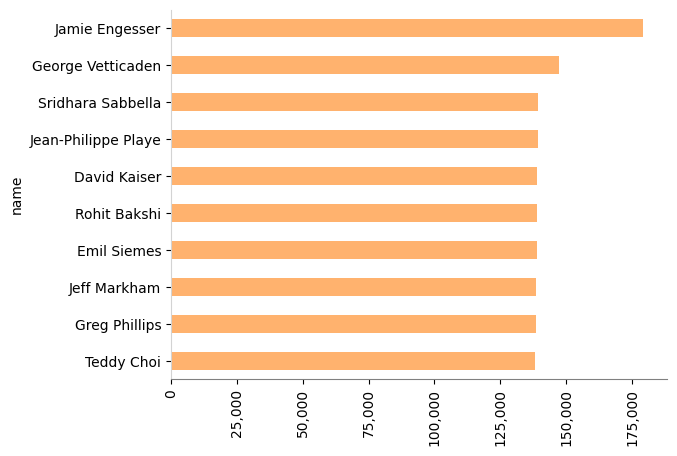

In [17]:
# Creación de un gráfico de barras horizontales
# La columna 'name' pasa a ser el nombre de las filas
top10 = top10.set_index("name")

# Paleta de colores:
#   tab:blue     tab:red       tab:pink
#   tab:orange   tab:purple    tab:gray
#   tab:green    tab:brown     tab:olive
#   tab:cyan
top10["miles_logged"].plot.barh(color="tab:orange", alpha=0.6)

plt.gca().invert_yaxis()

plt.gca().get_xaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ","))
)

plt.xticks(rotation=90)

plt.gca().spines["left"].set_color("lightgray")
plt.gca().spines["bottom"].set_color("gray")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.savefig("../submission/top10_drivers.png", bbox_inches="tight")

In [18]:
# Cierre de la conexión a la base de datos
connection.close()